# 03 — Fixed-256-D layer-set selection and representation ablations

This notebook consumes the completed frozen SfM cache. It never re-extracts
DINO features. Its output dimension is fixed at 256 so that layer-set selection
is not confounded by descriptor capacity.

It compares frozen Final CLS, a trainable final-CLS projection, multi-level CLS
concatenation, and global-local fusion with Uniform, Static, and Dynamic layer
weighting. The student manually records the selected layer set after reviewing
SfM-only results. This notebook does not choose a final model and must not use
RevisitOP.


In [1]:
# Run this first in every fresh Colab runtime. It intentionally does not use PYTHONPATH.
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import importlib
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get('CBIR_REPO_URL', 'https://github.com/armin-faraji/LightweightCBIR.git')
REPO_REVISION = os.environ.get('CBIR_REPO_REVISION', 'main')
PROJECT_ROOT = Path('/content/lightweight-cbir')
if not PROJECT_ROOT.is_dir():
    subprocess.run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)], check=True)
    subprocess.run(['git', '-C', str(PROJECT_ROOT), 'checkout', REPO_REVISION], check=True)
os.chdir(PROJECT_ROOT)
required_project_files = (
    PROJECT_ROOT / 'pyproject.toml',
    PROJECT_ROOT / 'src' / 'cbir' / '__init__.py',
    PROJECT_ROOT / 'src' / 'cbir' / 'artifacts.py',
)
missing_project_files = [
    str(path.relative_to(PROJECT_ROOT)) for path in required_project_files if not path.is_file()
]
if missing_project_files:
    raise RuntimeError(
        'The cloned repository does not contain the required project code: '
        + ', '.join(missing_project_files)
    )
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', '--no-deps', '--force-reinstall', '.'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'h5py', 'scipy', 'PyYAML', 'tqdm', 'matplotlib', 'Pillow'], check=True)

importlib.invalidate_caches()
import cbir
print('cbir package:', cbir.__file__)

from cbir.artifacts import create_artifact_run, make_artifact_run_id
from cbir.cloud import mount_colab_drive, runtime_report, write_runtime_report
from cbir.config import config_to_dict, load_project_config
from cbir.utils import stable_hash

PERSISTENT_ROOT = mount_colab_drive() / 'lightweight-cbir'
PERSISTENT_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('TORCH_HOME', str(PERSISTENT_ROOT / 'torch_hub'))
CONFIG_PATH = Path('configs/colab.yaml')
cfg = load_project_config(CONFIG_PATH)
FIXED_OUTPUT_DIM = 256
cfg = replace(cfg, fusion=replace(cfg.fusion, output_dim=FIXED_OUTPUT_DIM))
environment = runtime_report(project_root=PROJECT_ROOT)
config_fingerprint = stable_hash(config_to_dict(cfg))
RUN_ID = make_artifact_run_id(
    notebook='03', git_sha=environment['git_sha'], config_fingerprint=config_fingerprint
)
ARTIFACT_RUN = create_artifact_run(
    PROJECT_ROOT / 'outputs',
    '03',
    run_id=RUN_ID,
    metadata={'git_sha': environment['git_sha'], 'config_fingerprint': config_fingerprint},
)
LOCAL_OUTPUT_DIR = ARTIFACT_RUN.local_dir
DRIVE_OUTPUT_ROOT = PERSISTENT_ROOT / 'notebook_outputs'
write_runtime_report(
    LOCAL_OUTPUT_DIR,
    project_root=PROJECT_ROOT,
    extra={'notebook': '03', 'config': str(CONFIG_PATH), 'fixed_output_dim': FIXED_OUTPUT_DIM},
)
shutil.copy2(CONFIG_PATH, ARTIFACT_RUN.path_for('config.yaml'))
ARTIFACT_RUN.write_json('effective_config.json', config_to_dict(cfg))
print('Project:', PROJECT_ROOT)
print('Artifacts:', LOCAL_OUTPUT_DIR)
print('Layer-selection descriptor dimension:', FIXED_OUTPUT_DIM)


Mounted at /content/drive
Project: /content/lightweight-cbir
Artifacts: /content/lightweight-cbir/outputs/03/20260804T153756Z__nb-03__git-c74a82003804__cfg-d4f7521f8b98
Layer-selection descriptor dimension: 256


## Restore metadata and the completed frozen feature cache


In [2]:
from cbir.cache import FeatureShardReader
from cbir.cloud import publish_file, stage_file
from cbir.data.sfm import Sfm30kMetadata
from cbir.workflow import restore_complete_sfm_cache

LOCAL_SFM_ROOT = cfg.sfm.metadata_path.parent
DRIVE_SFM_ROOT = PERSISTENT_ROOT / 'datasets' / 'sfm30k'
metadata_files = (cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
LOCAL_SFM_ROOT.mkdir(parents=True, exist_ok=True)
if not all(path is not None and path.is_file() for path in metadata_files):
    if all(path is not None and (DRIVE_SFM_ROOT / path.name).is_file() for path in metadata_files):
        for path in metadata_files:
            assert path is not None
            stage_file(DRIVE_SFM_ROOT / path.name, path)
    else:
        subprocess.run(
            [sys.executable, 'scripts/prepare_sfm30k.py', '--config', str(CONFIG_PATH), '--image-source', 'none'],
            cwd=PROJECT_ROOT,
            check=True,
        )
        for path in metadata_files:
            assert path is not None
            publish_file(path, DRIVE_SFM_ROOT / path.name)
if cfg.sfm.names_clusters_path is None:
    raise ValueError('configs/colab.yaml must define sfm.names_clusters_path')
metadata = Sfm30kMetadata.from_official_files(cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
cache_location = restore_complete_sfm_cache(cfg, metadata)
reader = FeatureShardReader(cache_location.local_dir)
# Training batches draw pairs from many shards in random order. Keep every
# local shard in RAM and preload once, avoiding repeated torch.load calls.
reader.max_cached_shards = len(reader.manifest.shards)
warmup_ids = tuple(shard.image_ids[0] for shard in reader.manifest.shards)
_ = reader.fetch(
    warmup_ids,
    layer_indices=reader.manifest.layer_indices,
    local_kind=cfg.fusion.local_kind,
)
del warmup_ids, _
if set(reader.image_ids) != set(metadata.image_ids()):
    raise RuntimeError('restored cache does not contain exactly the full SfM-30k protocol image IDs')
val_ids = metadata.image_ids('val')
val_cases = metadata.build_validation_cases()
ARTIFACT_RUN.write_json('cache_restore.json', {
    'cache_name': cache_location.cache_name,
    'fingerprint': cache_location.fingerprint,
    'local_dir': str(cache_location.local_dir),
    'drive_dir': None if cache_location.drive_dir is None else str(cache_location.drive_dir),
})
cache_size_gib = sum(shard.bytes for shard in reader.manifest.shards) / 2**30
print(
    f'Using restored cache: {cache_location.local_dir} '
    f'({len(reader.manifest.shards)} shards, {cache_size_gib:.2f} GiB retained in RAM)'
)


Using restored cache: /content/cbir_cache/sfm30k__dinov2-vits14-reg__13224b93d7d2 (115 shards, 0.74 GiB retained in RAM)


## B0 — Frozen Final CLS baseline


In [3]:
from cbir.evaluation import evaluate_sfm_verified_pairs, final_cls_descriptors_from_cache

baseline = final_cls_descriptors_from_cache(reader, val_ids)
baseline_report = evaluate_sfm_verified_pairs(baseline, val_ids, val_cases)
baseline_metrics = {
    'label': 'Final CLS — 384-D (frozen)',
    'descriptor_dimension': 384,
    'recall_at_1': baseline_report.recall_at_1,
    'recall_at_5': baseline_report.recall_at_5,
    'recall_at_10': baseline_report.recall_at_10,
    'mrr': baseline_report.mrr,
}
ARTIFACT_RUN.write_json('baseline_metrics.json', baseline_metrics)
print(baseline_metrics)


{'label': 'Final CLS — 384-D (frozen)', 'descriptor_dimension': 384, 'recall_at_1': 0.9201655824955648, 'recall_at_5': 0.9461856889414547, 'recall_at_10': 0.9574216439976345, 'mrr': 0.9336657129040622}


## Declare fixed-256-D experiments

The four candidate layer sets are tested with multi-level CLS concatenation and
all three global-local layer-weighting variants. The final CLS projection is a
single 256-D trained control.


In [4]:
from dataclasses import replace

from cbir.cloud import publish_file
from cbir.config import config_to_dict, train_fingerprint
from cbir.fusion import build_descriptor_head
from cbir.plotting import HorizontalReference, SeriesData, plot_series
from cbir.training import HeadTrainer
from cbir.utils import atomic_write_json, seed_everything

# This is the only experiment declaration for Notebook 03. All runs use 256-D
# descriptors. Layer numbers remain one-based in the notebook/report and are
# converted only when building the DINO configuration.
LAYER_SETS_ONE_BASED = (
    (4, 8, 12),
    (10, 11, 12),
    (8, 10, 12),
    (6, 9, 12),
)

EXPERIMENT_SPECS = (
    {
        'name': 'final_cls_projection_256',
        'label': 'Final CLS + projection — 256-D',
        'head_kind': 'final_cls_projection',
        'gate_mode': None,
        'layers_one_based': (12,),
    },
    *tuple(
        spec
        for layers in LAYER_SETS_ONE_BASED
        for spec in (
            {
                'name': 'cls_concat_' + '_'.join(map(str, layers)),
                'label': f'Multi-level CLS concatenation ({", ".join(map(str, layers))}) — 256-D',
                'head_kind': 'cls_concat',
                'gate_mode': None,
                'layers_one_based': layers,
            },
            {
                'name': 'uniform_layer_weighting_' + '_'.join(map(str, layers)),
                'label': f'Uniform layer weighting ({", ".join(map(str, layers))}) — 256-D',
                'head_kind': 'global_local',
                'gate_mode': 'uniform',
                'layers_one_based': layers,
            },
            {
                'name': 'static_layer_weighting_' + '_'.join(map(str, layers)),
                'label': f'Static layer weighting ({", ".join(map(str, layers))}) — 256-D',
                'head_kind': 'global_local',
                'gate_mode': 'static',
                'layers_one_based': layers,
            },
            {
                'name': 'dynamic_layer_weighting_' + '_'.join(map(str, layers)),
                'label': f'Dynamic layer weighting ({", ".join(map(str, layers))}) — 256-D',
                'head_kind': 'global_local',
                'gate_mode': 'dynamic',
                'layers_one_based': layers,
            },
        )
    ),
)
EXPERIMENTS_BY_NAME = {spec['name']: spec for spec in EXPERIMENT_SPECS}
EXPERIMENT_NAMES = tuple(spec['name'] for spec in EXPERIMENT_SPECS)
if len(EXPERIMENTS_BY_NAME) != len(EXPERIMENT_SPECS):
    raise ValueError('Experiment names must be unique')
for spec in EXPERIMENT_SPECS:
    layers_one_based = tuple(int(layer) for layer in spec['layers_one_based'])
    if len(set(layers_one_based)) != len(layers_one_based):
        raise ValueError(f"{spec['name']} has duplicate layer indices")
    if min(layers_one_based) < 1 or max(layers_one_based) > cfg.backbone.num_blocks:
        raise ValueError(f"{spec['name']} has layers outside the backbone range")
    if spec['head_kind'] == 'global_local' and spec['gate_mode'] not in {'uniform', 'static', 'dynamic'}:
        raise ValueError(f"{spec['name']} has invalid layer weighting")
    if spec['head_kind'] != 'global_local' and spec['gate_mode'] is not None:
        raise ValueError(f"{spec['name']} must not define layer weighting")

PERSISTENT_CHECKPOINT_ROOT = PERSISTENT_ROOT / 'checkpoints' / '03' / ARTIFACT_RUN.run_id
histories = {}
ablation_results = {}


def zero_based_layers(spec):
    return tuple(int(layer) - 1 for layer in spec['layers_one_based'])


def write_experiment_summary():
    ARTIFACT_RUN.write_json('experiment_summary.json', {
        'baseline': baseline_metrics,
        'fixed_output_dim': FIXED_OUTPUT_DIM,
        'experiment_specs': list(EXPERIMENT_SPECS),
        'experiments': ablation_results,
    })


def record_experiment(experiment_name):
    if experiment_name in ablation_results:
        print('Already completed in this runtime:', experiment_name)
        return histories[experiment_name], ablation_results[experiment_name]
    spec = EXPERIMENTS_BY_NAME[experiment_name]
    fusion_cfg = replace(
        cfg.fusion,
        layer_indices=zero_based_layers(spec),
        output_dim=FIXED_OUTPUT_DIM,
        head_kind=spec['head_kind'],
        gate_mode=spec['gate_mode'],
    )
    run_fingerprint = train_fingerprint(
        cache_fingerprint=reader.manifest.fingerprint,
        fusion=fusion_cfg,
        training=cfg.training,
    )
    local_checkpoint_dir = ARTIFACT_RUN.path_for(Path('checkpoints') / experiment_name)
    persistent_checkpoint = PERSISTENT_CHECKPOINT_ROOT / experiment_name / 'best.pt'

    def publish_best_checkpoint(local_path):
        publish_file(local_path, persistent_checkpoint)

    seed_everything(cfg.training.seed)
    head = build_descriptor_head(fusion_cfg)
    trainable_parameter_count = sum(parameter.numel() for parameter in head.parameters())
    trainer = HeadTrainer(
        head=head,
        reader=reader,
        train_pairs=metadata.train_pairs,
        fusion_config=fusion_cfg,
        training_config=cfg.training,
        validation_cases=val_cases,
        validation_image_ids=val_ids,
        output_dir=local_checkpoint_dir,
        checkpoint_callback=publish_best_checkpoint,
    )
    history = trainer.fit()
    if history.best_checkpoint is None or history.best_epoch is None:
        raise RuntimeError(f'{experiment_name} did not produce a selected checkpoint')
    best_epoch_metrics = history.epochs[history.best_epoch]
    result = {
        'experiment_label': spec['label'],
        'head_kind': spec['head_kind'],
        'layer_weighting': spec['gate_mode'],
        'layer_indices_one_based': list(spec['layers_one_based']),
        'fusion_config': config_to_dict(fusion_cfg),
        'training_config': config_to_dict(cfg.training),
        'run_fingerprint': run_fingerprint,
        'trainable_parameter_count': trainable_parameter_count,
        'best_epoch': history.best_epoch + 1,
        'best_metric': history.best_metric,
        'best_epoch_metrics': best_epoch_metrics,
        'local_checkpoint': str(history.best_checkpoint),
        'persistent_checkpoint': str(persistent_checkpoint),
    }
    histories[experiment_name] = history
    ablation_results[experiment_name] = result
    write_experiment_summary()
    print(f"{spec['label']}: best SfM validation R@1={history.best_metric:.4f} at epoch {history.best_epoch + 1}")
    return history, result


def run_group(layers_one_based):
    suffix = '_'.join(map(str, layers_one_based))
    names = (
        'cls_concat_' + suffix,
        'uniform_layer_weighting_' + suffix,
        'static_layer_weighting_' + suffix,
        'dynamic_layer_weighting_' + suffix,
    )
    return [record_experiment(name) for name in names]

write_experiment_summary()
print('Declared trainable experiments:', len(EXPERIMENT_NAMES))


Declared trainable experiments: 17


## B1 — Final CLS + projection — 256-D


In [5]:
record_experiment('final_cls_projection_256')


Final CLS + projection — 256-D: best SfM validation R@1=0.9178 at epoch 3


(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.14161253891384798, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.911886457717327, 'val_recall_at_5': 0.9438202247191011, 'val_recall_at_10': 0.9591957421643997, 'val_mrr': 0.9282714585787396}, {'epoch': 1.0, 'loss': 0.0782304515595417, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.9130691898285038, 'val_recall_at_5': 0.9455943228858663, 'val_recall_at_10': 0.960969840331165, 'val_mrr': 0.928540629411543}, {'epoch': 2.0, 'loss': 0.06009612240064179, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.9178001182732111, 'val_recall_at_5': 0.9485511531638084, 'val_recall_at_10': 0.9621525724423418, 'val_mrr': 0.9320537780352465}, {'epoch': 3.0, 'loss': 0.048631561073153064, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.911886457717327, 'val_recall_at_5': 0.9455943228858663, 'val_recall

## Candidate layer set: (4, 8, 12)


In [6]:
run_group((4, 8, 12))


Multi-level CLS concatenation (4, 8, 12) — 256-D: best SfM validation R@1=0.9237 at epoch 23
Uniform layer weighting (4, 8, 12) — 256-D: best SfM validation R@1=0.9243 at epoch 17
Static layer weighting (4, 8, 12) — 256-D: best SfM validation R@1=0.9243 at epoch 17
Dynamic layer weighting (4, 8, 12) — 256-D: best SfM validation R@1=0.9243 at epoch 17


[(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.231396707565591, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.9065641632170314, 'val_recall_at_5': 0.9402720283855707, 'val_recall_at_10': 0.9591957421643997, 'val_mrr': 0.9244505101150176}, {'epoch': 1.0, 'loss': 0.08319744446901887, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.9053814311058546, 'val_recall_at_5': 0.9438202247191011, 'val_recall_at_10': 0.9574216439976345, 'val_mrr': 0.9235677375047765}, {'epoch': 2.0, 'loss': 0.06063288947060912, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.9130691898285038, 'val_recall_at_5': 0.9503252513305737, 'val_recall_at_10': 0.9633353045535187, 'val_mrr': 0.9304491151009501}, {'epoch': 3.0, 'loss': 0.046655798520989, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.9154346540508574, 'val_recall_at_5': 0.9461856889414547, 'val_recal

## Candidate layer set: (10, 11, 12)


In [7]:
run_group((10, 11, 12))


Multi-level CLS concatenation (10, 11, 12) — 256-D: best SfM validation R@1=0.9231 at epoch 8
Uniform layer weighting (10, 11, 12) — 256-D: best SfM validation R@1=0.9213 at epoch 7
Static layer weighting (10, 11, 12) — 256-D: best SfM validation R@1=0.9213 at epoch 7
Dynamic layer weighting (10, 11, 12) — 256-D: best SfM validation R@1=0.9202 at epoch 7


[(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.17466549109175114, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.8982850384387936, 'val_recall_at_5': 0.9390892962743939, 'val_recall_at_10': 0.9574216439976345, 'val_mrr': 0.9181236845755304}, {'epoch': 1.0, 'loss': 0.07304627709168117, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.9053814311058546, 'val_recall_at_5': 0.9384979302188055, 'val_recall_at_10': 0.9574216439976345, 'val_mrr': 0.9206934591157385}, {'epoch': 2.0, 'loss': 0.05170647724291236, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.911886457717327, 'val_recall_at_5': 0.9503252513305737, 'val_recall_at_10': 0.9627439384979303, 'val_mrr': 0.9301857305121762}, {'epoch': 3.0, 'loss': 0.038191000557997366, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.9142519219396806, 'val_recall_at_5': 0.9485511531638084, 'val_r

## Candidate layer set: (8, 10, 12)


In [8]:
run_group((8, 10, 12))


Multi-level CLS concatenation (8, 10, 12) — 256-D: best SfM validation R@1=0.9261 at epoch 22
Uniform layer weighting (8, 10, 12) — 256-D: best SfM validation R@1=0.9243 at epoch 22
Static layer weighting (8, 10, 12) — 256-D: best SfM validation R@1=0.9225 at epoch 8
Dynamic layer weighting (8, 10, 12) — 256-D: best SfM validation R@1=0.9261 at epoch 22


[(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.20229473344843427, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.9030159668835009, 'val_recall_at_5': 0.9426374926079243, 'val_recall_at_10': 0.9603784742755765, 'val_mrr': 0.9217782053707272}, {'epoch': 1.0, 'loss': 0.07797860005833365, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.908929627439385, 'val_recall_at_5': 0.9408633944411591, 'val_recall_at_10': 0.9586043761088113, 'val_mrr': 0.9244677130037883}, {'epoch': 2.0, 'loss': 0.05581367722408699, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.9172087522176227, 'val_recall_at_5': 0.9491425192193969, 'val_recall_at_10': 0.9627439384979303, 'val_mrr': 0.9330753000957965}, {'epoch': 3.0, 'loss': 0.04152370200033298, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.9160260201064458, 'val_recall_at_5': 0.9473684210526315, 'val_re

## Candidate layer set: (6, 9, 12)


In [9]:
run_group((6, 9, 12))


Multi-level CLS concatenation (6, 9, 12) — 256-D: best SfM validation R@1=0.9273 at epoch 22
Uniform layer weighting (6, 9, 12) — 256-D: best SfM validation R@1=0.9231 at epoch 8
Static layer weighting (6, 9, 12) — 256-D: best SfM validation R@1=0.9231 at epoch 8
Dynamic layer weighting (6, 9, 12) — 256-D: best SfM validation R@1=0.9231 at epoch 8


[(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.2180467747320368, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.9036073329390893, 'val_recall_at_5': 0.9414547604967475, 'val_recall_at_10': 0.9591957421643997, 'val_mrr': 0.9221907690334824}, {'epoch': 1.0, 'loss': 0.0812691254490094, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.9071555292726198, 'val_recall_at_5': 0.9396806623299823, 'val_recall_at_10': 0.9580130100532229, 'val_mrr': 0.9237203144063258}, {'epoch': 2.0, 'loss': 0.05822821578576115, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.9166173861620343, 'val_recall_at_5': 0.9491425192193969, 'val_recall_at_10': 0.9627439384979303, 'val_mrr': 0.9318306804007117}, {'epoch': 3.0, 'loss': 0.04434225038548762, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.9130691898285038, 'val_recall_at_5': 0.9467770549970431, 'val_rec

## Audit, plots, and dynamic-layer-weighting diagnostics


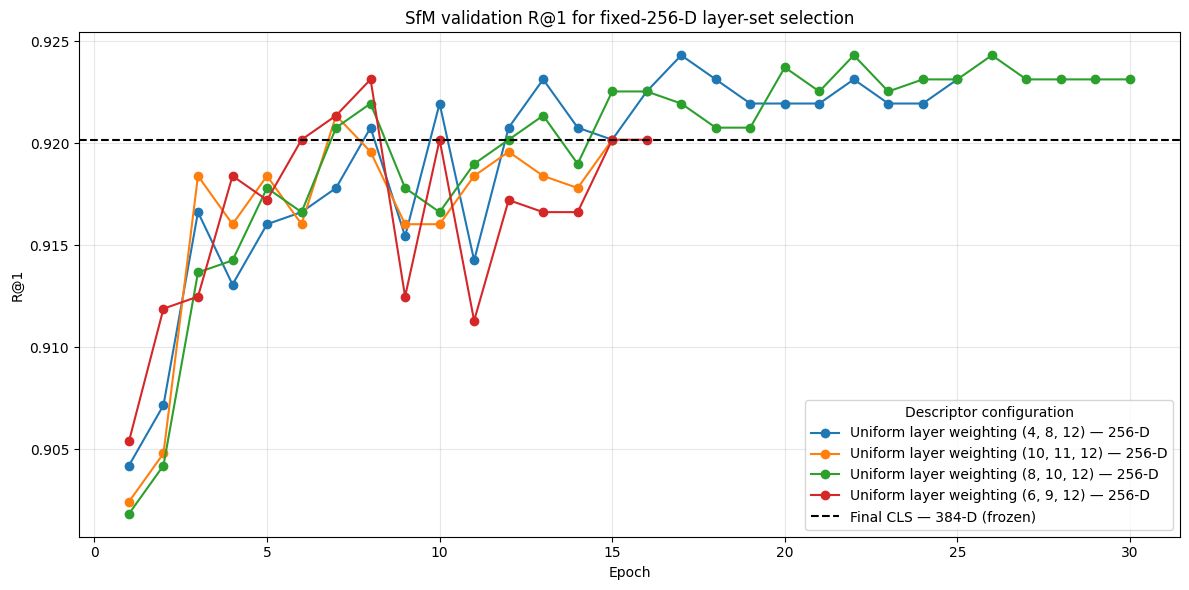

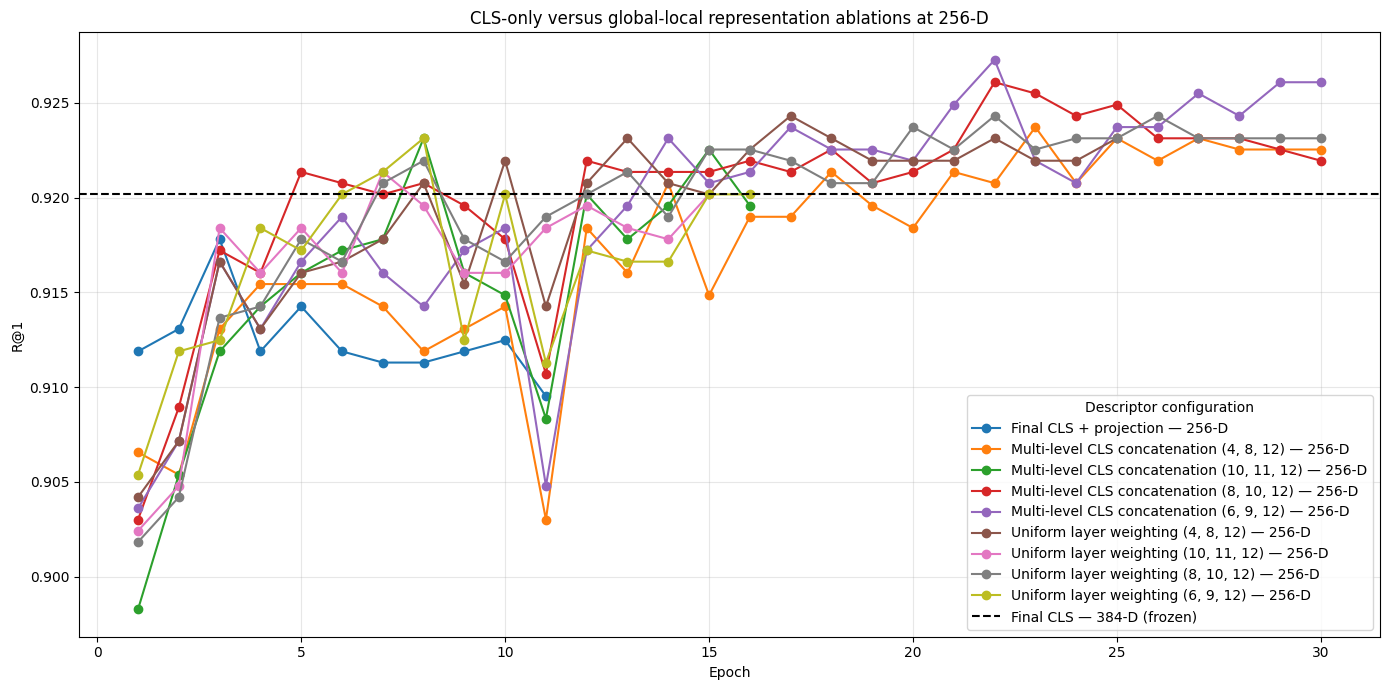

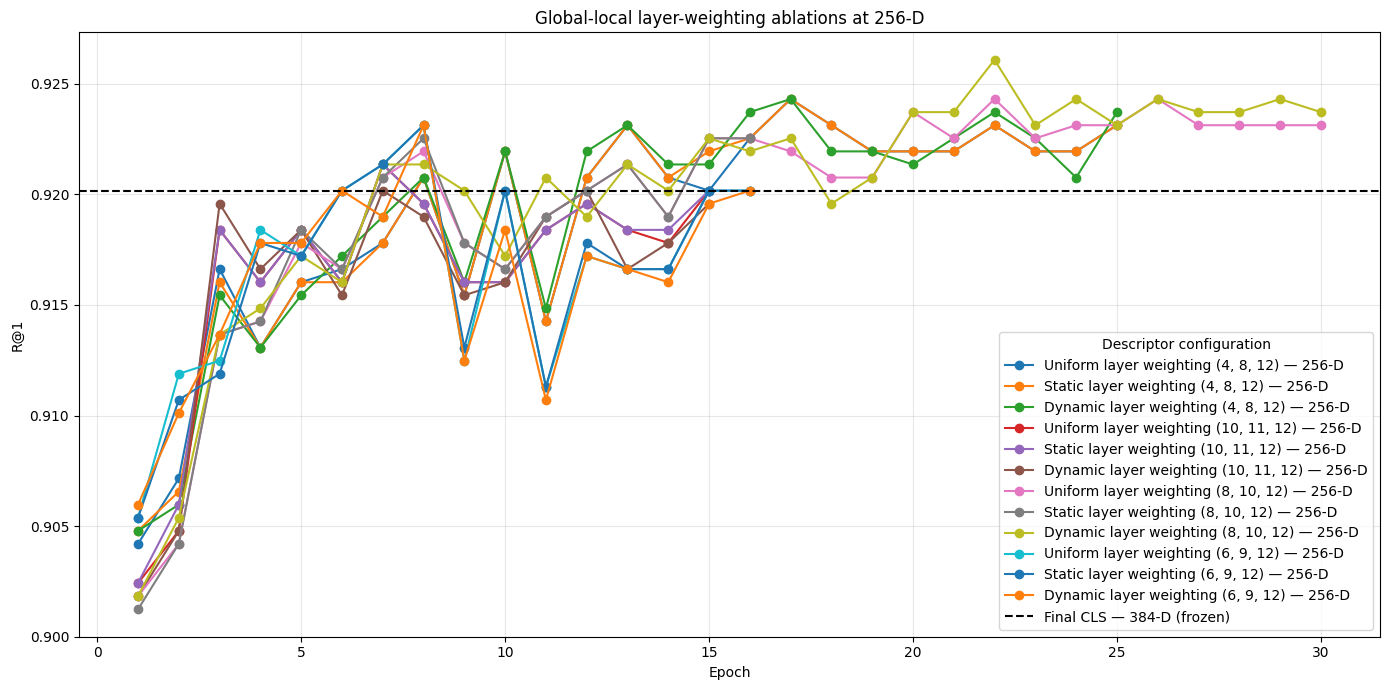

{'final_cls_384_frozen': 0.9201655824955648, 'final_cls_projection_256': 0.9178001182732111, 'cls_concat_4_8_12': 0.9237137788290952, 'uniform_layer_weighting_4_8_12': 0.9243051448846836, 'static_layer_weighting_4_8_12': 0.9243051448846836, 'dynamic_layer_weighting_4_8_12': 0.9243051448846836, 'cls_concat_10_11_12': 0.9231224127735068, 'uniform_layer_weighting_10_11_12': 0.9213483146067416, 'static_layer_weighting_10_11_12': 0.9213483146067416, 'dynamic_layer_weighting_10_11_12': 0.9201655824955648, 'cls_concat_8_10_12': 0.9260792430514488, 'uniform_layer_weighting_8_10_12': 0.9243051448846836, 'static_layer_weighting_8_10_12': 0.9225310467179184, 'dynamic_layer_weighting_8_10_12': 0.9260792430514488, 'cls_concat_6_9_12': 0.9272619751626257, 'uniform_layer_weighting_6_9_12': 0.9231224127735068, 'static_layer_weighting_6_9_12': 0.9231224127735068, 'dynamic_layer_weighting_6_9_12': 0.9231224127735068}


In [10]:
from itertools import combinations

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as functional
from IPython.display import display

from cbir.cache import sha256_file
from cbir.fusion import MultiLevelGlobalLocalFusion

missing_experiments = [name for name in EXPERIMENT_NAMES if name not in ablation_results]
if missing_experiments:
    raise RuntimeError('Run every declared experiment before audit: ' + ', '.join(missing_experiments))

# The frozen B0 line belongs on the key layer-selection R@1 plot. It has no
# training epochs, so it is a horizontal labelled reference rather than a curve.
primary_uniform_names = [
    'uniform_layer_weighting_' + '_'.join(map(str, layers))
    for layers in LAYER_SETS_ONE_BASED
]
primary_uniform_series = {
    EXPERIMENTS_BY_NAME[name]['label']: SeriesData(
        x=[int(epoch['epoch']) + 1 for epoch in histories[name].epochs],
        y=[epoch['val_recall_at_1'] for epoch in histories[name].epochs],
    )
    for name in primary_uniform_names
}
figure_selection, _ = plot_series(
    primary_uniform_series,
    title='SfM validation R@1 for fixed-256-D layer-set selection',
    xlabel='Epoch',
    ylabel='R@1',
    legend_title='Descriptor configuration',
    horizontal_references={
        baseline_metrics['label']: HorizontalReference(baseline_metrics['recall_at_1'])
    },
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/layer_selection_validation_r1.png'),
)
display(figure_selection)
plt.close(figure_selection)

# Compare the new CLS-only controls directly with the primary uniform
# global-local representation for every candidate layer set.
representation_names = [
    'final_cls_projection_256',
    *['cls_concat_' + '_'.join(map(str, layers)) for layers in LAYER_SETS_ONE_BASED],
    *primary_uniform_names,
]
representation_series = {
    EXPERIMENTS_BY_NAME[name]['label']: SeriesData(
        x=[int(epoch['epoch']) + 1 for epoch in histories[name].epochs],
        y=[epoch['val_recall_at_1'] for epoch in histories[name].epochs],
    )
    for name in representation_names
}
figure_representation, _ = plot_series(
    representation_series,
    title='CLS-only versus global-local representation ablations at 256-D',
    xlabel='Epoch',
    ylabel='R@1',
    legend_title='Descriptor configuration',
    horizontal_references={
        baseline_metrics['label']: HorizontalReference(baseline_metrics['recall_at_1'])
    },
    fig_size=(14, 7),
    save_path=ARTIFACT_RUN.path_for('figures/representation_ablation_validation_r1.png'),
)
display(figure_representation)
plt.close(figure_representation)

all_global_local_names = [
    name for name, spec in EXPERIMENTS_BY_NAME.items()
    if spec['head_kind'] == 'global_local'
]
all_global_local_series = {
    EXPERIMENTS_BY_NAME[name]['label']: SeriesData(
        x=[int(epoch['epoch']) + 1 for epoch in histories[name].epochs],
        y=[epoch['val_recall_at_1'] for epoch in histories[name].epochs],
    )
    for name in all_global_local_names
}
figure_weighting, _ = plot_series(
    all_global_local_series,
    title='Global-local layer-weighting ablations at 256-D',
    xlabel='Epoch',
    ylabel='R@1',
    legend_title='Descriptor configuration',
    horizontal_references={
        baseline_metrics['label']: HorizontalReference(baseline_metrics['recall_at_1'])
    },
    fig_size=(14, 7),
    save_path=ARTIFACT_RUN.path_for('figures/global_local_weighting_validation_r1.png'),
)
display(figure_weighting)
plt.close(figure_weighting)

summary_rows = [
    {
        'name': 'final_cls_384_frozen',
        **baseline_metrics,
        'head_kind': 'frozen_final_cls',
        'layer_weighting': None,
        'layer_indices_one_based': [12],
        'trainable_parameter_count': 0,
    },
    *[
        {'name': name, **result}
        for name, result in ablation_results.items()
    ],
]
ARTIFACT_RUN.write_json('result_table.json', summary_rows)
print({row['name']: row.get('best_metric', row.get('recall_at_1')) for row in summary_rows})

# LEMG diagnostics are intentionally restricted to dynamic global-local heads.
dynamic_diagnostics = {}
sample_image_ids = tuple(val_ids[: min(512, len(val_ids))])
for name in all_global_local_names:
    spec = EXPERIMENTS_BY_NAME[name]
    if spec['gate_mode'] != 'dynamic':
        continue
    result = ablation_results[name]
    checkpoint = torch.load(result['persistent_checkpoint'], map_location='cpu', weights_only=False)
    fusion_payload = dict(checkpoint['fusion_config'])
    fusion_payload['layer_indices'] = tuple(fusion_payload['layer_indices'])
    from cbir.config import FusionConfig
    fusion_cfg = FusionConfig(**fusion_payload)
    head = MultiLevelGlobalLocalFusion.from_config(fusion_cfg).to(cfg.training.device).eval()
    head.load_state_dict(checkpoint['model_state_dict'])
    sample = reader.fetch(sample_image_ids, layer_indices=fusion_cfg.layer_indices, local_kind=fusion_cfg.local_kind)
    sample = {key: value.to(cfg.training.device) for key, value in sample.items()}
    with torch.inference_mode():
        _, diagnostics = head(sample['cls'], sample['local'], sample['entropy'], return_diagnostics=True)
    assert diagnostics.layer_weights is not None
    assert diagnostics.entropy_penalty_scale is not None
    dynamic_diagnostics[name] = {
        'label': spec['label'],
        'entropy_penalty_scale': float(diagnostics.entropy_penalty_scale.detach().cpu()),
        'weight_mean': [float(value) for value in diagnostics.layer_weights.mean(dim=0).detach().cpu()],
        'weight_std': [float(value) for value in diagnostics.layer_weights.std(dim=0, unbiased=False).detach().cpu()],
    }
ARTIFACT_RUN.write_json('dynamic_layer_weighting_diagnostics.json', dynamic_diagnostics)
write_experiment_summary()


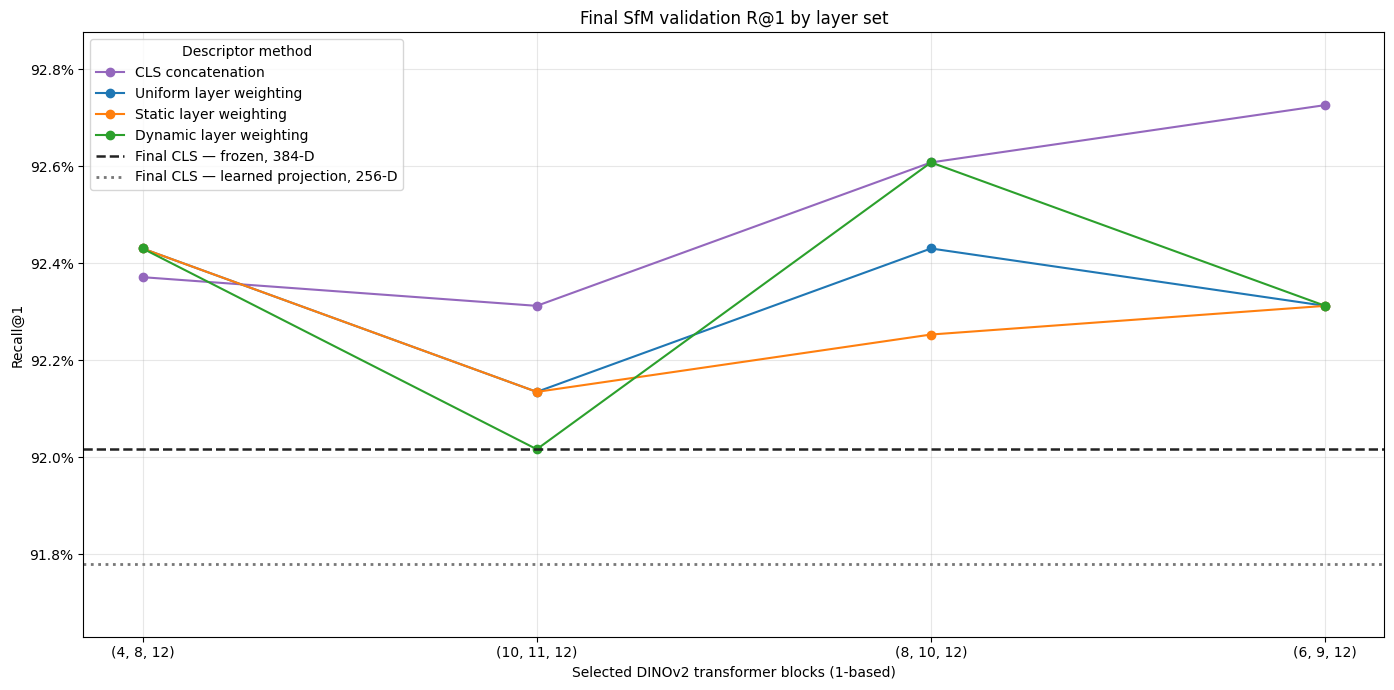

In [15]:
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from cbir.plotting import HorizontalReference, SeriesData, plot_series


# Build the same R@1 dictionary that Notebook 03 prints at the end.
r1_results = {
    "final_cls_384_frozen": baseline_metrics["recall_at_1"],
    **{
        name: result["best_metric"]
        for name, result in ablation_results.items()
    },
}

layer_sets = list(LAYER_SETS_ONE_BASED)
x_positions = list(range(len(layer_sets)))
layer_labels = [f"({', '.join(map(str, layers))})" for layers in layer_sets]

methods = [
    ("cls_concat", "CLS concatenation", "#9467bd"),
    ("uniform_layer_weighting", "Uniform layer weighting", "#1f77b4"),
    ("static_layer_weighting", "Static layer weighting", "#ff7f0e"),
    ("dynamic_layer_weighting", "Dynamic layer weighting", "#2ca02c"),
]

series = {}
colors = {}

for prefix, label, color in methods:
    experiment_names = [
        f"{prefix}_{'_'.join(map(str, layers))}"
        for layers in layer_sets
    ]

    missing = [name for name in experiment_names if name not in r1_results]
    if missing:
        raise KeyError(f"Missing R@1 results: {missing}")

    series[label] = SeriesData(
        x=x_positions,
        y=[r1_results[name] for name in experiment_names],
    )
    colors[label] = color

all_scores = list(r1_results.values())

figure, axis = plot_series(
    series,
    title="Final SfM validation R@1 by layer set",
    xlabel="Selected DINOv2 transformer blocks (1-based)",
    ylabel="Recall@1",
    colors=colors,
    legend_title="Descriptor method",
    horizontal_references={
        "Final CLS — frozen, 384-D": HorizontalReference(
            r1_results["final_cls_384_frozen"],
            color="#222222",
            linestyle="--",
            linewidth=1.8,
        ),
        "Final CLS — learned projection, 256-D": HorizontalReference(
            r1_results["final_cls_projection_256"],
            color="#777777",
            linestyle=":",
            linewidth=2.0,
        ),
    },
    fig_size=(14, 7),
    save_path=ARTIFACT_RUN.path_for("figures/final_r1_by_layer_set.png"),
)

axis.set_xticks(x_positions)
axis.set_xticklabels(layer_labels)
axis.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
axis.set_ylim(min(all_scores) - 0.0015, max(all_scores) + 0.0015)

display(figure)
plt.close(figure)

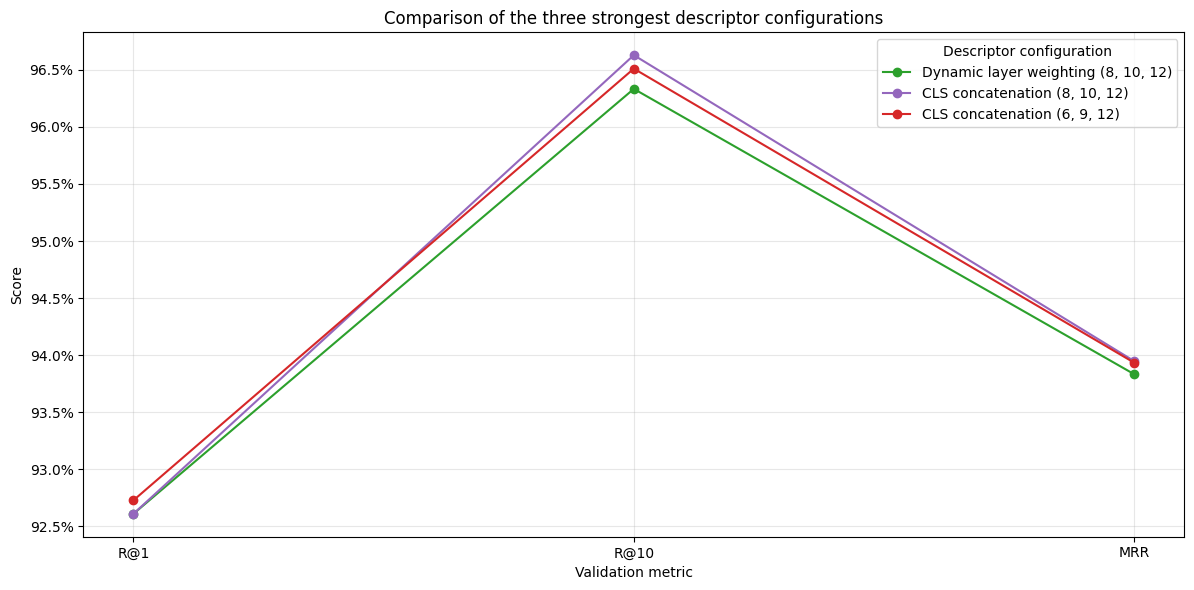

In [16]:
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from cbir.plotting import SeriesData, plot_series


comparison_experiments = {
    "Dynamic layer weighting (8, 10, 12)": "dynamic_layer_weighting_8_10_12",
    "CLS concatenation (8, 10, 12)": "cls_concat_8_10_12",
    "CLS concatenation (6, 9, 12)": "cls_concat_6_9_12",
}

metric_definitions = [
    ("val_recall_at_1", "R@1"),
    ("val_recall_at_10", "R@10"),
    ("val_mrr", "MRR"),
]

missing = [
    name
    for name in comparison_experiments.values()
    if name not in ablation_results
]
if missing:
    raise RuntimeError(f"Run these experiments first: {missing}")

x_positions = list(range(len(metric_definitions)))
metric_labels = [label for _, label in metric_definitions]

comparison_series = {
    display_label: SeriesData(
        x=x_positions,
        y=[
            ablation_results[experiment_name]["best_epoch_metrics"][metric_key]
            for metric_key, _ in metric_definitions
        ],
    )
    for display_label, experiment_name in comparison_experiments.items()
}

colors = {
    "Dynamic layer weighting (8, 10, 12)": "#2ca02c",
    "CLS concatenation (8, 10, 12)": "#9467bd",
    "CLS concatenation (6, 9, 12)": "#d62728",
}

all_metric_values = [
    value
    for series_data in comparison_series.values()
    for value in series_data.y
]

figure, axis = plot_series(
    comparison_series,
    title="Comparison of the three strongest descriptor configurations",
    xlabel="Validation metric",
    ylabel="Score",
    colors=colors,
    legend_title="Descriptor configuration",
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for(
        "figures/selected_configurations_r1_r10_mrr.png"
    ),
)

axis.set_xticks(x_positions)
axis.set_xticklabels(metric_labels)
axis.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
axis.set_ylim(min(all_metric_values) - 0.002, max(all_metric_values) + 0.002)

display(figure)
plt.close(figure)

## Manually record the SfM-selected layer set

Set the variable in the following cell only after inspecting the SfM-only
results. This is intentionally a manual research decision; it does not apply an
automatic tie-breaking rule. It writes an intermediate layer-selection record,
not a final-model lock.


In [13]:
from cbir.utils import atomic_write_json

# Select the layer set manually after inspecting only the SfM results above.
# Example: SELECTED_LAYER_SET_ONE_BASED = (8, 10, 12)
SELECTED_LAYER_SET_ONE_BASED = (8, 10, 12)

if SELECTED_LAYER_SET_ONE_BASED is None:
    print('No layer set recorded yet. Inspect the SfM-only outputs, set SELECTED_LAYER_SET_ONE_BASED, then rerun this cell.')
else:
    chosen_layers = tuple(int(layer) for layer in SELECTED_LAYER_SET_ONE_BASED)
    if chosen_layers not in LAYER_SETS_ONE_BASED:
        raise ValueError('Choose one of the declared layer sets: ' + repr(LAYER_SETS_ONE_BASED))
    layer_selection = {
        'selected_on': 'Manual student decision after SfM-30k validation inspection only',
        'notebook_run_id': ARTIFACT_RUN.run_id,
        'cache_fingerprint': reader.manifest.fingerprint,
        'selected_layer_indices_one_based': list(chosen_layers),
        'available_layer_sets_one_based': [list(layers) for layers in LAYER_SETS_ONE_BASED],
        'fixed_output_dim': FIXED_OUTPUT_DIM,
        'baseline': baseline_metrics,
        'experiment_results': ablation_results,
    }
    layer_selection_path = PERSISTENT_ROOT / 'selected' / 'layer_selection.json'
    atomic_write_json(layer_selection_path, layer_selection)
    ARTIFACT_RUN.write_json('layer_selection.json', layer_selection)
    print('Recorded manual SfM-only layer selection:', chosen_layers)


Recorded manual SfM-only layer selection: (8, 10, 12)


## Publish Notebook 03 outputs to Drive


In [14]:
published_output = ARTIFACT_RUN.publish(DRIVE_OUTPUT_ROOT)
print('Validated notebook artifacts published to:', published_output)


Validated notebook artifacts published to: /content/drive/MyDrive/lightweight-cbir/notebook_outputs/03/20260804T153756Z__nb-03__git-c74a82003804__cfg-d4f7521f8b98__rev-25e9dd7718e4
